In [1]:
import tensorflow as tf
import cv2
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
import time
import os

In [2]:
patch_size = 30
kernel_size = patch_size
image_size = 256
descriptor_dimension = 4

max_rotation = 360
rotation_multiple = 36
max_skew = 0

margin = 1
threshold = 0.4
learning_rate = 0.1e-2
optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
cos_sim = tf.keras.losses.CosineSimilarity()
batch_size = 256
epochs = 100000
model_path = "filters_model.h5"
backup_model_path = "backup_filters_model.h5"

In [3]:
centre_to_top_right = np.array([[1,0,-math.ceil(image_size/2)],
                                [0,1,-math.ceil(image_size/2)],
                                [0,0,1]])
top_right_to_centre = np.array([[1,0,math.ceil(image_size/2)],
                                [0,1,math.ceil(image_size/2)],
                                [0,0,1]])

patch_centre_to_top_right = np.array([[1,0,-math.ceil(patch_size/2)],
                                [0,1,-math.ceil(patch_size/2)],
                                [0,0,1]])
patch_top_right_to_centre = np.array([[1,0,math.ceil(patch_size//2)],
                                [0,1,math.ceil(patch_size//2)],
                                [0,0,1]])

def create_rotational_matrix(rotation, axis = "z"):
    rotation = np.radians(rotation)
    s = np.sin(rotation)
    c = np.cos(rotation)
    if axis == "z":
        return np.array([[c, -s, 0],
                          [s, c, 0],
                          [0, 0, 1]])
        
def create_skew_matrix(skew_x, skew_y):
     return np.array([[1, skew_x, 0],
                     [skew_y, 1, 0],
                     [0, 0, 1]])

In [4]:
def get_random_homography_matrix():
    rotation = np.random.uniform(0,max_rotation)
    rotation = (rotation//rotation_multiple) * rotation_multiple
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(patch_top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), patch_centre_to_top_right))
    return homography_matrix

In [5]:
class CustomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_dir_path, batch_size = 128):
        
        self.img_list = []
        for image in os.listdir(image_dir_path):
            if image == ".DS_Store":
                continue
            img = cv2.imread(os.path.join(image_dir_path, image))
            img = cv2.resize(img, (image_size, image_size))
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            img = img/255
            self.img_list.append(img)
            
        self.batchsize = batch_size  
                
    def __len__(self):
        return math.ceil(((image_size - patch_size)**2)/self.batchsize)
        
    def __getitem__(self, batch):
        original_images = []
        matches = []
        non_matches = []
        for _ in range(self.batchsize):
            current_image_no = np.random.randint(0, len(self.img_list))
            current_image = self.img_list[current_image_no]
            x = np.random.randint(0,image_size - patch_size)
            y = np.random.randint(0,image_size - patch_size)
            current_patch = current_image[x:x+patch_size, y:y+patch_size]
            current_patch = cv2.blur(current_patch, (3,3))
            transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            transformed_current_patch = cv2.blur(transformed_current_patch, (3,3))
            
            current_patch = np.expand_dims(current_patch, axis = -1)
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            
            original_images.append(current_patch)
            matches.append(transformed_current_patch)
            
            X = np.random.randint(0,image_size - patch_size)
            Y = np.random.randint(0,image_size - patch_size)
            random_image_no = np.random.randint(0, len(self.img_list))
            random_image = self.img_list[random_image_no]
            while(x==X & y==Y & random_image_no == current_image_no):
                X = np.random.randint(0,image_size - patch_size)
                Y = np.random.randint(0,image_size - patch_size)
                
            current_patch = random_image[X:X+patch_size, Y:Y+patch_size]
            transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            transformed_current_patch = cv2.blur(transformed_current_patch, (3,3))
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            non_matches.append(transformed_current_patch)
        
            original_images = np.array(original_images)
            matches = np.array(matches)
            non_matches = np.array(non_matches)
            
            # original_images = np.array(original_images > threshold, dtype=np.double)
            # matches = np.array(matches > threshold, dtype=np.double)
            # non_matches = np.array(non_matches > threshold, dtype=np.double)
            
        return original_images, matches, non_matches

In [6]:
# class ChannelNormalization(tf.keras.layers.Layer):
#     def __init__(self):
#         super(ChannelNormalization, self).__init__()

#     def call(self, inputs):
#         return tf.keras.backend.l2_normalize(inputs, axis=-1)
    
#     def compute_output_shape(self, input_shape):
#         return input_shape
    
#     def build(self, input_shape):
#         super(ChannelNormalization, self).build(input_shape)
        
#     def get_config(self):
#         return super(ChannelNormalization, self).get_config()
    
#     @classmethod
#     def from_config(cls, config):
#         instance = cls()
#         return instance

In [7]:
# class ClippingLayer(tf.keras.layers.Layer):
#     def __init__(self):
#         super(ClippingLayer, self).__init__()

#     def call(self, inputs):
#         return tf.keras.backend.clip(inputs, min_value=0.0, max_value=256.0)
    
#     def compute_output_shape(self, input_shape):
#         return input_shape
    
#     def build(self, input_shape):
#         super(ClippingLayer, self).build(input_shape)
        
#     def get_config(self):
#         return super(ClippingLayer, self).get_config()
    
#     @classmethod
#     def from_config(cls, config):
#         instance = cls()
#         return instance

In [8]:
# def get_model(input_shape, descriptor_dimension):
#     inp = tf.keras.layers.Input(input_shape)
#     out = tf.keras.layers.Conv2D(descriptor_dimension, kernel_size)(inp)
#     # out = ClippingLayer()(out)
#     out = ChannelNormalization()(out)
    
#     model = tf.keras.models.Model(inputs = inp, outputs = out)
#     return model

In [9]:
# def custom_loss(original_desc, matches, non_matches):
#     original_desc = tf.squeeze(original_desc)
#     matches = tf.squeeze(matches)
#     non_matches = tf.squeeze(non_matches)
    
#     return tf.reduce_mean((1 - tf.matmul(original_desc, tf.transpose(matches))) + \
#                             abs(tf.matmul(original_desc, tf.transpose(matches))) + \
#                             abs(tf.matmul(matches, tf.transpose(non_matches))))
    

In [10]:
# model = get_model((patch_size, patch_size, 1), descriptor_dimension)
# model.summary()

In [11]:
# data_gen = CustomDataGenerator("test/img/cinema1.jpeg", batch_size)

# for epoch in range(epochs):
#     epoch_loss = 0
#     print(f"Epoch {epoch} starting...")
#     for batch in range(data_gen.__len__()):
#         all_patches, matches, non_matches = data_gen.__getitem__(batch)
#         with tf.GradientTape() as tape:
#             all_predictions = model(all_patches)
#             matches_predictions = model(matches)
#             non_matches_predictions = model(non_matches)
#             loss = custom_loss(all_predictions, matches_predictions, non_matches_predictions)
#             # print(loss)
#             epoch_loss += loss
#             gradients = tape.gradient(loss, model.trainable_variables)
#             optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        
#         # if batch%5==0:
#         #     print(loss.numpy())
#     # val_generator.on_epoch_end()
    
#     try:
#         model.save(model_path)
#         model.save(backup_model_path)
#     except Exception as e:
#         print("========= Note ================")
#         print("cant save last model")
#         print(e)
    
#     print(epoch_loss.numpy()/data_gen.__len__())
#     epoch_loss = 0

In [12]:
val_data_gen = CustomDataGenerator("test/img", 1)

In [13]:
# og, match, no_match = val_data_gen.__getitem__(0)
# fig, ax = plt.subplots(ncols=3, figsize = (11,5))
# # sns.heatmap(og[0,:,:,0], ax = ax[0], cbar = False, vmin=0, vmax=1)
# sns.heatmap(match[0,:,:,0], ax = ax[1], cbar = False, vmin=0, vmax=1)
# sns.heatmap(no_match[0,:,:,0], ax = ax[2], cbar = False, vmin=0, vmax=1)

In [14]:
filter = tf.random.uniform(shape=(patch_size, patch_size), minval=0, maxval=1, dtype=tf.double)
# filter = np.clip(filter, 0, 1)
cv2.imwrite("filters/initial_filter.jpg", np.array(filter*255))
filter = tf.Variable(tf.convert_to_tensor(filter))

In [15]:
# sns.heatmap(filter)

In [16]:
# bce = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(og[0,:,:,0], filter))
# # sns.heatmap(bce)


In [17]:
def custom_loss(desc1_og_img, desc1_trans_img, desc1_rand_img, sigmoid_filter):
    
    desc1_og_img_sum = tf.reduce_sum(desc1_og_img)
    desc1_trans_img_sum = tf.reduce_sum(desc1_trans_img)
    desc1_rand_img_sum = tf.reduce_sum(desc1_rand_img)
    # print(desc1_og_img_sum)
    # print(desc1_trans_img_sum)
    # print(desc1_rand_img_sum)
    descriptor_loss = tf.maximum(0, abs(desc1_og_img_sum - desc1_trans_img_sum) - abs(desc1_rand_img_sum - desc1_og_img_sum) + margin)
    h_m = get_random_homography_matrix()
    changed_sigmoid_filter = cv2.warpPerspective(sigmoid_filter.numpy(), h_m, (patch_size, patch_size))
    
    filter_loss = 1 - cos_sim(tf.reshape(changed_sigmoid_filter, [-1]), tf.reshape(sigmoid_filter, [-1]))
    
    loss = descriptor_loss + (2 * filter_loss)
    return loss

In [18]:
for i in range(epochs):
    og, match, no_match = val_data_gen.__getitem__(0)
    with tf.GradientTape() as tape:
        # desc1_og_img = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(og[0,:,:,0], filter))
        # desc1_trans_img = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(match[0,:,:,0], filter))
        # desc1_rand_img = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(no_match[0,:,:,0], filter))
        sigmoid_filter = tf.keras.activations.sigmoid(filter - 0.5)
        sigmoid_filter_1d = tf.reshape(sigmoid_filter, [-1])
        
        # desc1_og_img = tf.math.l2_normalize(og[0,:,:,0] @ sigmoid_filter)
        # desc1_trans_img = tf.math.l2_normalize(match[0,:,:,0] @ sigmoid_filter)
        # desc1_rand_img = tf.math.l2_normalize(no_match[0,:,:,0] @ sigmoid_filter)
        
        og = tf.reshape(og, [-1])
        match = tf.reshape(match, [-1])
        no_match = tf.reshape(no_match, [-1])
        
        desc1_og_img = cos_sim(og, sigmoid_filter_1d)
        # print(desc1_og_img)
        desc1_trans_img = cos_sim(sigmoid_filter_1d, match)
        desc1_rand_img = cos_sim(sigmoid_filter_1d, no_match)
        
        loss = custom_loss(desc1_og_img, desc1_trans_img, desc1_rand_img, sigmoid_filter)
        gradients = tape.gradient(loss, [filter])
        optimizer.apply_gradients(zip(gradients, [filter]))
    
    if i%500 == 0:
        # sns.heatmap(filter,cbar=False)
        t = time.time()
        cv2.imwrite(f"filters/filter1_{int(t)}.jpg", np.array(tf.keras.activations.sigmoid(filter) * 255))
        print(np.max(np.array(tf.keras.activations.sigmoid(filter) * 255)), np.min(np.array(tf.keras.activations.sigmoid(filter) * 255)))
        # plt.savefig(f"filters/filter1_{int(t)}.jpg")
        # filter = tf.Variable(tf.keras.activations.sigmoid(filter))
        # optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
        filter.assign_add(tf.random.uniform(shape=(patch_size, patch_size), minval=loss.numpy()*-0.6, maxval=loss.numpy()*0.6, dtype=tf.double))
        print(loss.numpy())
        

186.35401168368355 127.57716785604767
4.7455373
249.86024019644418 10.296693765436014
4.3624263
254.57738677682903 1.2812421275185297
4.1840487
254.929742553616 0.2863510162372894
4.1308627
254.97677092704888 0.039379059722931084
5.014559
254.9965755384553 0.002544792257352229
4.067095
254.99714257675834 0.0019045216683270865
4.0098243
254.9991586098407 0.006389627209083454
4.015167
254.99913409837984 0.0007673201475328924
3.819942
254.9997783791563 0.00019876386570676205
4.978858
254.99968098022796 3.298444347197153e-05
3.7614422
254.9999415515528 5.243024949874327e-06
3.9577615
254.99997754806293 2.7926540784887795e-06
3.8609424
254.9999860350737 6.20242598036718e-07
3.9122684
254.99999322617208 2.1110461926305842e-07
3.825282
254.9999987333352 1.1192949094678477e-06
3.8974552
254.9999997758409 1.578653511838106e-06
3.8228862
254.99999801758412 2.8327974792087856e-07
4.9938235
254.9999952539646 2.6539519060062743e-08
3.7825327
254.99999947909618 5.8194194959663336e-09
3.8358457
254.9

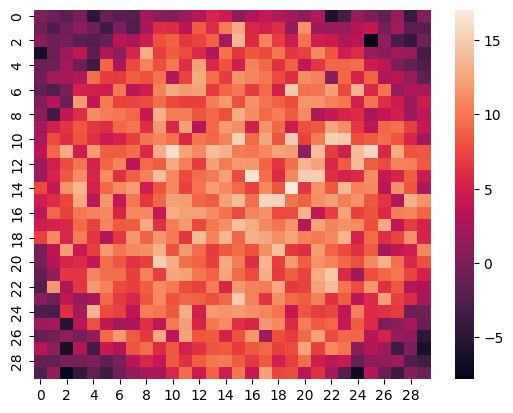

In [ ]:
sns.heatmap(filter)
t = time.time()
plt.savefig(f"filters/filter1_{int(t)}.jpg")

<Figure size 640x480 with 0 Axes>